In [156]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns

In [157]:
df=pd.read_excel(r"mobile_fraud.xlsx")

In [158]:
df.head()

,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud
0,PAYMENT,9839.64,170136.0,160296.36,0.0,0.0,0
1,PAYMENT,1864.28,21249.0,19384.72,0.0,0.0,0
2,TRANSFER,181.00,181.0,0.00,0.0,0.0,1
3,CASH_OUT,181.00,181.0,0.00,21182.0,0.0,1
4,PAYMENT,11668.14,41554.0,29885.86,0.0,0.0,0


In [159]:
# If fraud column doesn't exist (example logic)
# df['isFraud'] = df['amount'].apply(lambda x: 1 if x > 200000 else 0)

In [160]:
# To check variable/coloumn data types
df.dtypes

type               object
amount            float64
oldbalanceOrg     float64
newbalanceOrig    float64
oldbalanceDest    float64
newbalanceDest    float64
isFraud             int64
dtype: object

In [161]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3999 entries, 0 to 3998
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   type            3999 non-null   object 
 1   amount          3999 non-null   float64
 2   oldbalanceOrg   3999 non-null   float64
 3   newbalanceOrig  3999 non-null   float64
 4   oldbalanceDest  3999 non-null   float64
 5   newbalanceDest  3999 non-null   float64
 6   isFraud         3999 non-null   int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 218.8+ KB


In [162]:
df.duplicated().sum()

np.int64(0)

In [163]:
# To show column wise total missing values(null)
df.isnull().sum()

type              0
amount            0
oldbalanceOrg     0
newbalanceOrig    0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
dtype: int64

In [164]:
# To see discreptive stats of df
df.describe()

,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud
count,3.999000e+03,3.999000e+03,3.999000e+03,3.999000e+03,3.999000e+03,3999.000000
mean,9.730730e+04,9.759726e+05,9.988826e+05,8.042838e+05,9.729019e+05,0.006002
std,2.250008e+05,2.179107e+06,2.227147e+06,2.327724e+06,2.793499e+06,0.077246
min,6.420000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000
25%,3.977375e+03,4.560000e+02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000
50%,1.069623e+04,2.568881e+04,1.723080e+04,0.000000e+00,0.000000e+00,0.000000
75%,1.080888e+05,2.716136e+05,2.685602e+05,3.551205e+05,2.680215e+05,0.000000
max,3.776389e+06,1.222588e+07,1.245865e+07,1.951612e+07,1.916920e+07,1.000000


In [165]:
df.drop('type',axis=1).corr()

,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud
amount,1.000000,0.102192,0.103467,0.387273,0.460741,0.080468
oldbalanceOrg,0.102192,1.000000,0.998957,0.233472,0.181582,-0.023836
newbalanceOrig,0.103467,0.998957,1.000000,0.238394,0.183627,-0.034854
oldbalanceDest,0.387273,0.233472,0.238394,1.000000,0.898258,-0.026307
newbalanceDest,0.460741,0.181582,0.183627,0.898258,1.000000,-0.010200
isFraud,0.080468,-0.023836,-0.034854,-0.026307,-0.010200,1.000000


# visualization

In [166]:
df.tail()

,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud
3994,PAYMENT,13620.05,50465.00,36844.95,0.0,0.0,0
3995,PAYMENT,401.10,36844.95,36443.85,0.0,0.0,0
3996,PAYMENT,14694.94,234028.00,219333.06,0.0,0.0,0
3997,PAYMENT,11405.44,193320.70,181915.26,0.0,0.0,0
3998,PAYMENT,931.78,181915.26,180983.48,0.0,0.0,0


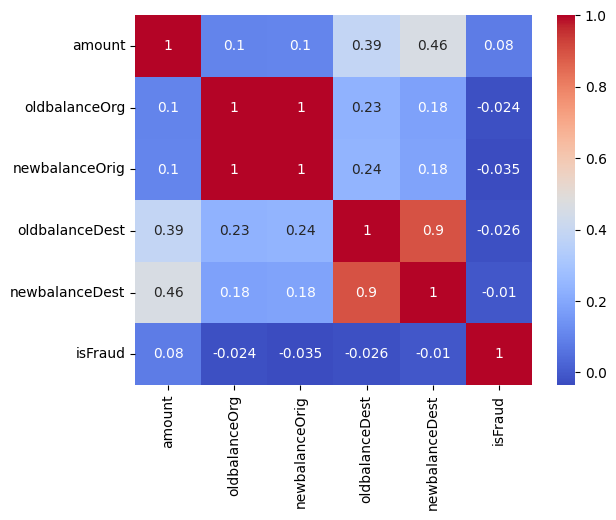

In [167]:
sns.heatmap(df.drop('type',axis=1).corr(),annot=True,cmap='coolwarm')
plt.show()

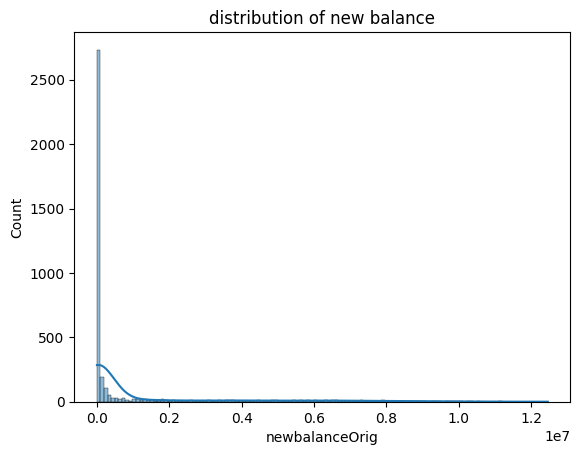

In [168]:
sns.histplot(df['newbalanceOrig'],kde=True)
plt.title('distribution of new balance')
plt.show()

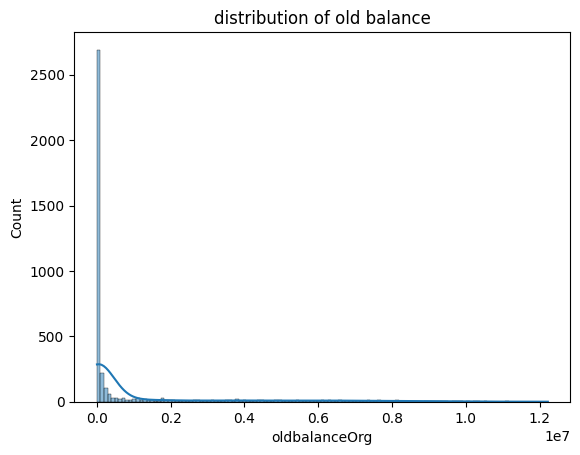

In [169]:
sns.histplot(df['oldbalanceOrg'],kde=True)
plt.title('distribution of old balance')
plt.show()

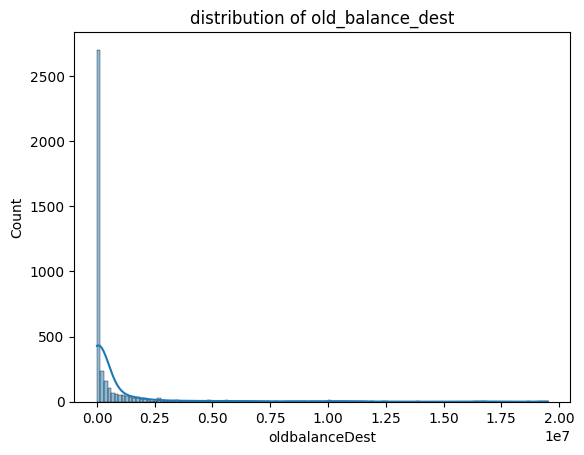

In [170]:
sns.histplot(df['oldbalanceDest'],kde=True)
plt.title('distribution of old_balance_dest')
plt.show()

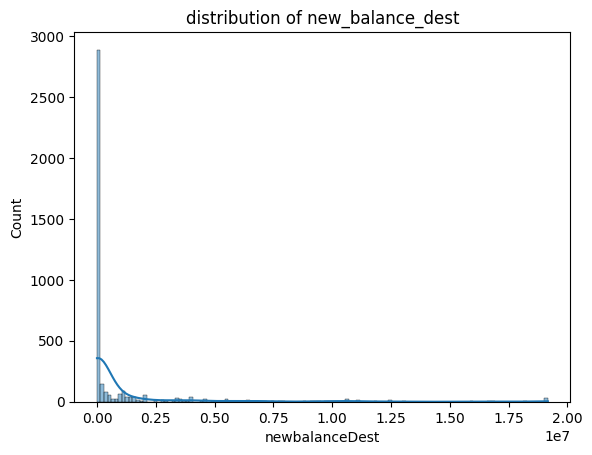

In [171]:
sns.histplot(df['newbalanceDest'],kde=True)
plt.title('distribution of new_balance_dest')
plt.show()

# Machine learning

In [172]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [173]:
df.head()

,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud
0,PAYMENT,9839.64,170136.0,160296.36,0.0,0.0,0
1,PAYMENT,1864.28,21249.0,19384.72,0.0,0.0,0
2,TRANSFER,181.00,181.0,0.00,0.0,0.0,1
3,CASH_OUT,181.00,181.0,0.00,21182.0,0.0,1
4,PAYMENT,11668.14,41554.0,29885.86,0.0,0.0,0


In [174]:
le=LabelEncoder()
df['type_encoded']=le.fit_transform(df['type'])
df.head()

,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,type_encoded
0,PAYMENT,9839.64,170136.0,160296.36,0.0,0.0,0,3
1,PAYMENT,1864.28,21249.0,19384.72,0.0,0.0,0,3
2,TRANSFER,181.00,181.0,0.00,0.0,0.0,1,4
3,CASH_OUT,181.00,181.0,0.00,21182.0,0.0,1,1
4,PAYMENT,11668.14,41554.0,29885.86,0.0,0.0,0,3


In [175]:
x=df.drop(['type','isFraud'],axis=1)
y=df['isFraud']


In [176]:
#standardization
x_stand=StandardScaler().fit_transform(x)
x_stand

array([[-0.38879236, -0.36984752, -0.37657639, -0.34556693, -0.34831708,
         0.62463029],
       [-0.42424271, -0.43818084, -0.43985431, -0.34556693, -0.34831708,
         0.62463029],
       [-0.43172486, -0.44785022, -0.44855924, -0.34556693, -0.34831708,
         1.37004854],
       ...,
       [-0.36721063, -0.34052359, -0.35006531, -0.34556693, -0.34831708,
         0.62463029],
       [-0.38183241, -0.35920665, -0.36686819, -0.34556693, -0.34831708,
         0.62463029],
       [-0.42838766, -0.3644413 , -0.36728661, -0.34556693, -0.34831708,
         0.62463029]], shape=(3999, 6))

In [177]:
x_train, x_test, y_train, y_test = train_test_split(
    x_stand, y, test_size=0.2, random_state=42
)

In [178]:
model1=LogisticRegression()
model1.fit(x_train,y_train)
y_pred_lr=model1.predict(x_test)

# logistic regression metrics

In [179]:
accuracy_score(y_test,y_pred_lr)

0.9925

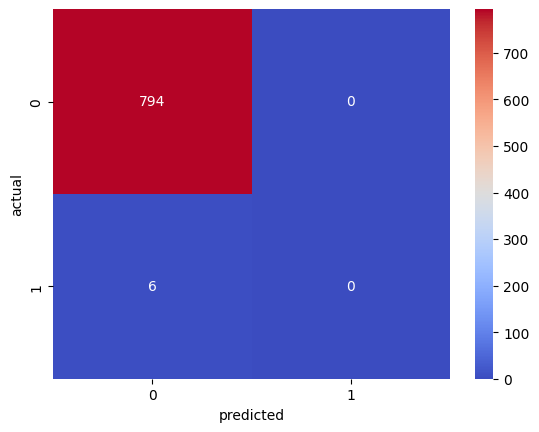

In [180]:
#confusion matrix
sns.heatmap(confusion_matrix(y_test,y_pred_lr),annot=True,fmt='d',cmap='coolwarm')
plt.xlabel('predicted')
plt.ylabel('actual')
plt.show()



In [181]:
print(classification_report(y_test,y_pred_lr))

              precision    recall  f1-score   support

           0       0.99      1.00      1.00       794
           1       0.00      0.00      0.00         6

    accuracy                           0.99       800
   macro avg       0.50      0.50      0.50       800
weighted avg       0.99      0.99      0.99       800



c:\Users\SIDDHARTHA\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\SIDDHARTHA\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\SIDDHARTHA\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.


# random forest classifier

In [182]:
model2=RandomForestClassifier()
model2.fit(x_train,y_train)
y_pred_rf=model2.predict(x_test)

In [183]:
accuracy_score(y_test,y_pred_rf)

0.99625

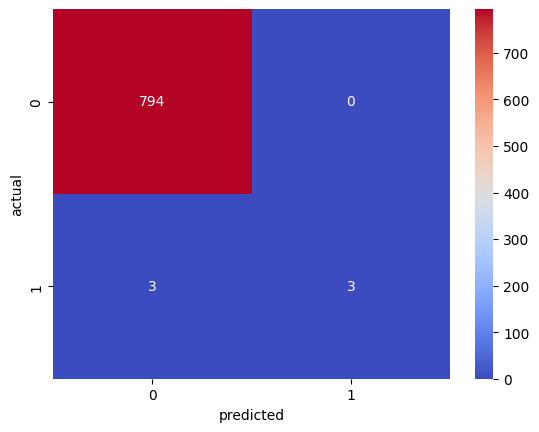

In [184]:
#confusion matrix
sns.heatmap(confusion_matrix(y_test,y_pred_rf),annot=True,fmt='d',cmap='coolwarm')
plt.xlabel('predicted')
plt.ylabel('actual')
plt.show()


In [185]:
print(classification_report(y_test,y_pred_rf))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       794
           1       1.00      0.50      0.67         6

    accuracy                           1.00       800
   macro avg       1.00      0.75      0.83       800
weighted avg       1.00      1.00      1.00       800

